# PopOut — Decision Tree AI Pipeline

This notebook covers the full decision-tree pipeline for learning to play PopOut:

1. **Dataset generation** — parallel self-play with the MCTS-Solver records (board state, best move) pairs
2. **Data exploration** — class distribution, feature overview
3. **ID3 classifier** — train on all features, inspect feature importance
4. **Feature sweep** — find the minimum number of features needed to play well
5. **Win-rate evaluation** — measure how often the tree beats FlatNumbaSolverMCTS

In [3]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.decision_tree.id3.learner import ID3Classifier
from src.decision_tree.dataset_generator import generate_dataset_parallel
from src.engine.standard.bitboard import PopOutBoard
from src.engine.standard.rules import evaluate_after_move, extended_features

plt.style.use('ggplot')
print(f'CPU cores available: {os.cpu_count()}')

CPU cores available: 16


## 1. Dataset Generation

Each worker plays one **complete game** from the empty board — both sides driven
by **FlatNumbaSolverMCTS** (full Numba JIT loop, 30–60k iter/s).  Every position
visited during the game is recorded as a `(board state, best move)` training pair.

This produces ~25–35 realistic samples per game covering opening, mid-game, and
end-game, and naturally includes the tactical positions where **pop moves** are
optimal — something random scrambling almost never generates.

The solver exits early once a position is **proven**, so most moves cost well
under the 100 000 iteration maximum.

In [4]:
N_GAMES      = 3_000   # full games to play if regenerating (~135K positions after mirroring)
ORACLE_ITERS = 100_000 # labeling oracle + opponent non-blunder strength
BLUNDER_RATE = 0.10    # probability the opponent drops to a weaker iteration count per move
DATA_PATH    = Path('../data/generated/popout_dt_dataset.csv')
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)
    print(f'Loaded existing dataset: {len(df)} rows ← {DATA_PATH}')
    print('Delete the file and re-run this cell to regenerate.')
else:
    print(f'Playing {N_GAMES} games | oracle={ORACLE_ITERS:,} iter/move | blunder_rate={BLUNDER_RATE}')
    print(f'Workers: {os.cpu_count()} cores  |  Engine: FlatNumbaSolverMCTS')
    t0 = time.perf_counter()
    df = generate_dataset_parallel(
        n_games=N_GAMES,
        oracle_iterations=ORACLE_ITERS,
        blunder_rate=BLUNDER_RATE,
        seed=42,
    )
    elapsed = time.perf_counter() - t0
    df.to_csv(DATA_PATH, index=False)
    print(f'Done in {elapsed:.1f} s  |  {len(df)} positions  |  {len(df)/N_GAMES:.1f} moves/game')
    print(f'Saved → {DATA_PATH}')

print(f'\nDataset: {df.shape[0]} rows × {df.shape[1]} columns')

Loaded existing dataset: 119676 rows ← ../data/generated/popout_dt_dataset.csv
Delete the file and re-run this cell to regenerate.

Dataset: 119676 rows × 52 columns


## 2. Data Exploration

In [6]:
TARGET       = 'best_move'
# is_proven is metadata used only for oversampling — never a tree input feature
FEATURE_COLS = [c for c in df.columns if c not in (TARGET, 'is_proven')]

print(f'Features : {len(FEATURE_COLS)}  ({FEATURE_COLS[:5]} ... {FEATURE_COLS[-1]})')
print(f'Classes  : {df[TARGET].nunique()} unique moves')
if 'is_proven' in df.columns:
    n_proven = int(df['is_proven'].sum())
    print(f'Proven positions: {n_proven} / {len(df)} ({n_proven/len(df):.1%})')
print()
df.head(3)

Features : 50  (['cell_0_0', 'cell_0_1', 'cell_0_2', 'cell_0_3', 'cell_0_4'] ... opp_wins_next)
Classes  : 14 unique moves
Proven positions: 57272 / 119676 (47.9%)



,cell_0_0,cell_0_1,cell_0_2,cell_0_3,cell_0_4,cell_0_5,cell_0_6,cell_1_0,cell_1_1,cell_1_2,...,current_player,threats_me,threats_opp,center_me,center_opp,phase,can_win,opp_wins_next,best_move,is_proven
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,drop_3,0
1,0,0,0,1,0,0,0,0,0,0,...,2,0,0,0,1,0,0,0,drop_3,0
2,0,0,0,1,0,0,0,0,0,0,...,1,0,0,1,1,0,0,0,drop_3,0


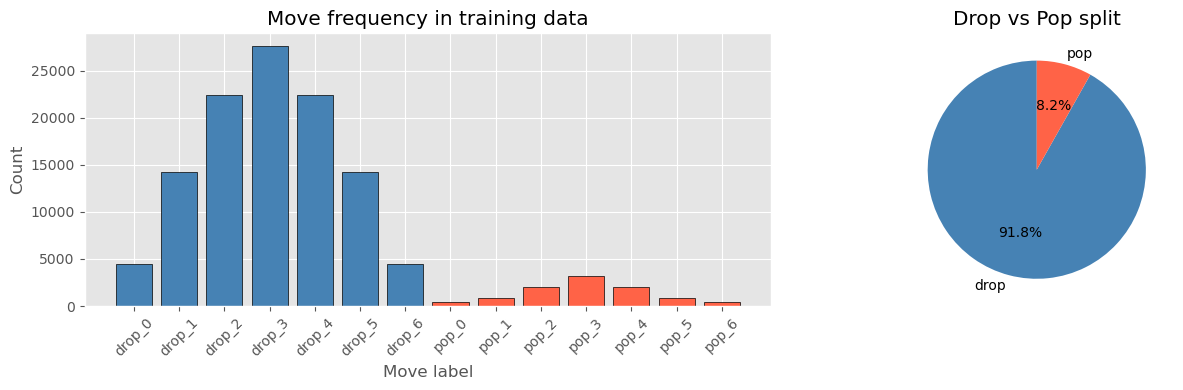

Drop moves: 109896 (91.8%)   Pop moves: 9780 (8.2%)


In [4]:
move_counts = df[TARGET].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Move frequency
colors = ['steelblue' if m.startswith('drop') else 'tomato' for m in move_counts.index]
axes[0].bar(move_counts.index, move_counts.values, color=colors, edgecolor='black')
axes[0].set_xlabel('Move label')
axes[0].set_ylabel('Count')
axes[0].set_title('Move frequency in training data')
axes[0].tick_params(axis='x', rotation=45)

# Drop vs pop split
n_drop = sum(1 for m in df[TARGET] if m.startswith('drop'))
n_pop  = len(df) - n_drop
axes[1].pie([n_drop, n_pop], labels=['drop', 'pop'], autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Drop vs Pop split')

plt.tight_layout()
plt.show()

print(f'Drop moves: {n_drop} ({n_drop/len(df):.1%})   Pop moves: {n_pop} ({n_pop/len(df):.1%})')

## 3. ID3 Classifier — Training

The board features from `to_feature_dict()` are already categorical:
- `cell_r_c` ∈ {0 = empty, 1 = player 1, 2 = player 2}  (42 features)
- `current_player` ∈ {1, 2}  (1 feature)

No discretisation step is needed — we pass them directly to `ID3Classifier`.

The dataset is split 80 / 20 for training and testing.  The model is the same
`ID3Classifier` from `src/decision_tree/id3/learner.py`.

In [5]:
OVERSAMPLE_FACTOR = 4   # proven positions are duplicated this many extra times

# Convert integer features to string so ID3Classifier groupby keys are consistent
df_str = df.copy()
for col in FEATURE_COLS:
    df_str[col] = df_str[col].astype(str)

# 80 / 20 split (stratified by move label)
df_train = df_str.sample(frac=0.8, random_state=42).reset_index(drop=True)
df_test  = df_str.drop(df_train.index).reset_index(drop=True)

# Oversample proven positions (WIN / LOSS / DRAW) so the tree prioritises
# the tactically decisive moments where the oracle's label is provably correct.
# is_proven is excluded from FEATURE_COLS so it never reaches the tree as input.
if 'is_proven' in df_train.columns:
    proven = df_train[df_train['is_proven'].astype(str) == '1']
    df_train_aug = pd.concat([df_train] + [proven] * OVERSAMPLE_FACTOR,
                             ignore_index=True)
    print(f'Proven rows: {len(proven)} ({len(proven)/len(df_train):.1%} of train)')
    print(f'After oversampling: {len(df_train_aug)} rows  '
          f'(proven share: {(len(proven)*(1+OVERSAMPLE_FACTOR))/len(df_train_aug):.1%})')
else:
    df_train_aug = df_train
    print('No is_proven column — skipping oversampling (regenerate dataset to enable).')

print(f'Train: {len(df_train)}  |  Test: {len(df_test)}')

clf_full = ID3Classifier(max_depth=10)
t0 = time.perf_counter()
clf_full.fit(df_train_aug[FEATURE_COLS + [TARGET]], target=TARGET)
train_time = time.perf_counter() - t0

train_acc = clf_full.score(df_train[FEATURE_COLS + [TARGET]], target=TARGET)
test_acc  = clf_full.score(df_test[FEATURE_COLS  + [TARGET]], target=TARGET)

print(f'Training time : {train_time:.2f} s')
print(f'Train accuracy: {train_acc:.3f}')
print(f'Test  accuracy: {test_acc:.3f}')

# Tactical accuracy breakdown
preds   = clf_full.predict(df_test[FEATURE_COLS])
correct = (preds == df_test[TARGET].astype(str))
print(f'\nTactical accuracy:')
for feat, val in [('can_win', '1'), ('opp_wins_next', '1')]:
    if feat in df_test.columns:
        mask = df_test[feat].astype(str) == val
        if mask.sum() > 0:
            print(f'  {feat}=1  (n={mask.sum():4d}): {correct[mask].mean():.3f}')
pop_mask = df_test[TARGET].str.startswith('pop')
if pop_mask.sum() > 0:
    print(f'  pop moves  (n={pop_mask.sum():4d}): {correct[pop_mask].mean():.3f}')

Proven rows: 45970 (48.0% of train)
After oversampling: 279621 rows  (proven share: 82.2%)
Train: 95741  |  Test: 23935
Training time : 188.18 s
Train accuracy: 0.854
Test  accuracy: 0.843

Tactical accuracy:
  can_win=1  (n=1179): 0.791
  opp_wins_next=1  (n=3575): 0.750
  pop moves  (n=2119): 0.894


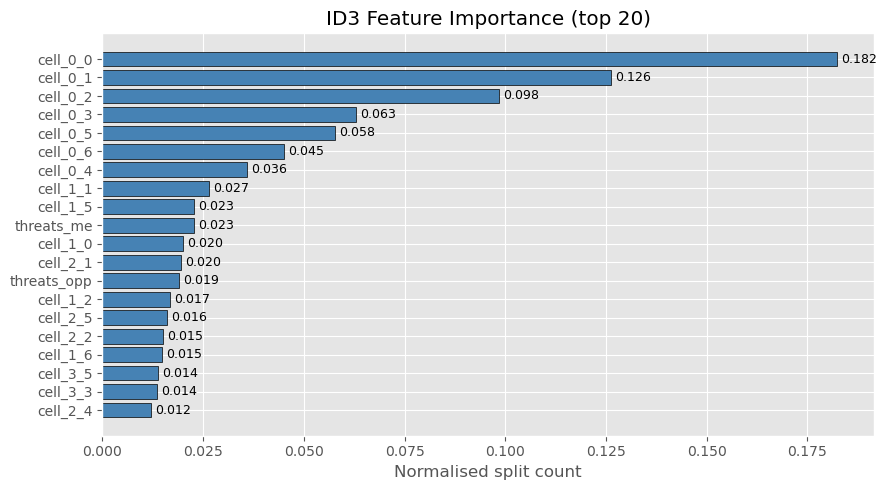

In [6]:
importance = clf_full.get_feature_importance()

# Show top 20 most-used features
top_n = 20
top_feats  = list(importance.keys())[:top_n]
top_scores = list(importance.values())[:top_n]

plt.figure(figsize=(9, 5))
bars = plt.barh(top_feats[::-1], top_scores[::-1], color='steelblue', edgecolor='black')
for bar, val in zip(bars, top_scores[::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=9)
plt.xlabel('Normalised split count')
plt.title(f'ID3 Feature Importance (top {top_n})')
plt.tight_layout()
plt.show()

## 4. Feature Sweep

We rank all features by their **information gain** on the training set, then train
separate ID3 trees using only the top-K features.  The accuracy curve reveals the
**minimum feature budget** the game requires to achieve good move prediction.

In [7]:
# Rank features by IG computed on the training set
_ranker = ID3Classifier()
ig_scores = {
    feat: _ranker.information_gain(df_train, feat, TARGET)
    for feat in FEATURE_COLS
}
ranked_features = sorted(ig_scores, key=ig_scores.get, reverse=True)

print('Top 10 features by information gain:')
for i, f in enumerate(ranked_features[:10], 1):
    print(f'  {i:2d}. {f:<18}  IG = {ig_scores[f]:.4f}')

Top 10 features by information gain:
   1. center_me           IG = 0.6927
   2. center_opp          IG = 0.6145
   3. cell_3_3            IG = 0.4637
   4. phase               IG = 0.3645
   5. cell_2_3            IG = 0.3504
   6. cell_0_2            IG = 0.3295
   7. cell_0_4            IG = 0.3293
   8. cell_1_2            IG = 0.2486
   9. cell_1_4            IG = 0.2473
  10. cell_1_3            IG = 0.2248


In [8]:
K_VALUES = [1, 3, 5, 10, 15, 20, 30, len(FEATURE_COLS)]
sweep_results = []

for k in K_VALUES:
    top_k_feats = ranked_features[:k]
    cols = top_k_feats + [TARGET]

    clf_k = ID3Classifier(max_depth=15)
    clf_k.fit(df_train[cols], target=TARGET)

    train_a = clf_k.score(df_train[cols], target=TARGET)
    test_a  = clf_k.score(df_test[cols],  target=TARGET)
    sweep_results.append({'K': k, 'Train': train_a, 'Test': test_a})
    print(f'K={k:3d}  train={train_a:.3f}  test={test_a:.3f}')

sweep_df = pd.DataFrame(sweep_results)

K=  1  train=0.399  test=0.391
K=  3  train=0.446  test=0.453
K=  5  train=0.462  test=0.469
K= 10  train=0.689  test=0.694
K= 15  train=0.781  test=0.778
K= 20  train=0.822  test=0.816
K= 30  train=0.850  test=0.841
K= 50  train=0.857  test=0.847


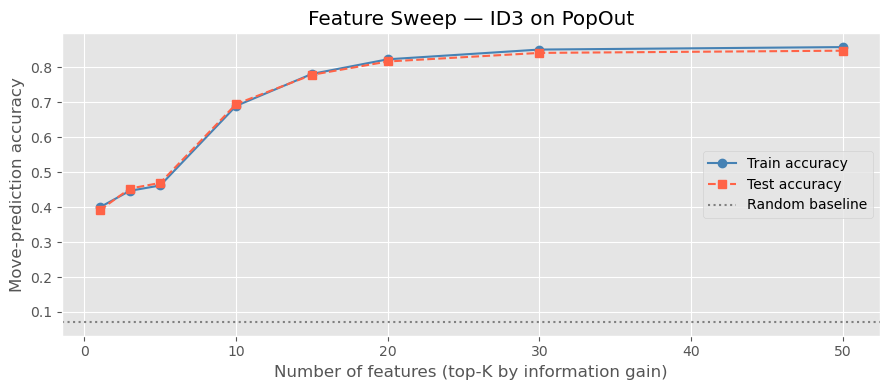

In [9]:
plt.figure(figsize=(9, 4))
plt.plot(sweep_df['K'], sweep_df['Train'], 'o-', label='Train accuracy', color='steelblue')
plt.plot(sweep_df['K'], sweep_df['Test'],  's--', label='Test accuracy',  color='tomato')
plt.axhline(1/df[TARGET].nunique(), color='gray', linestyle=':', label='Random baseline')
plt.xlabel('Number of features (top-K by information gain)')
plt.ylabel('Move-prediction accuracy')
plt.title('Feature Sweep — ID3 on PopOut')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Win-Rate Evaluation

The ID3 tree is evaluated against two engine families at multiple iteration counts:

| Engine | Iterations tested | Notes |
|---|---|---|
| **FlatNumbaMCTS** | 100 · 500 · 1 000 · 5 000 · 10 000 | Standard MCTS, no proof propagation |
| **FlatNumbaSolverMCTS** | 1 000 · 5 000 · 10 000 · 50 000 · 100 000 | MCTS-Solver, exits when proven & all root moves tried |

30 games per configuration, alternating sides for balance.
When the tree predicts an illegal move it falls back to a random legal move.

The classifier used here is loaded from `data/generated/id3_model.pkl` — the
**same model used by the GUI** (trained on the full dataset).  If the pickle is
missing, run `python scripts/train_id3.py` once to generate it.

## 5a. Raw-Features Depth Sweep

Before training the full raw-features model (`ID3AgentRaw`) we find the
optimal `max_depth` by sweeping on a **stratified subsample** of the dataset.
Training on ~30 k rows is fast enough to sweep many depths while still giving
a reliable accuracy signal.

Features used: raw cell occupancy (`cell_r_c`) + `current_player` only —
identical to what `ID3AgentRaw` will train on.
Proven positions are oversampled 10× so the subsample reflects the same
class balance as the full training run.

/tmp/ipykernel_22945/1359516073.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=SAMPLE_FRAC, random_state=42))


Original sample : 5,984 rows  (proven share: 48.6%)
After oversampling: 35,094 rows  (proven share: 91.2%)
Train: 28,075  |  Test: 7,019
Features: 43  (raw cells + current_player)
Depths  : [3, 5, 8, 10, 12, 15, 18, 20, 25, 30]

depth= 3  train=0.393  test=0.361  (5.3s)
depth= 5  train=0.614  test=0.616  (9.0s)
depth= 8  train=0.843  test=0.846  (20.3s)
depth=10  train=0.866  test=0.868  (25.1s)
depth=12  train=0.868  test=0.870  (27.8s)
depth=15  train=0.868  test=0.870  (33.0s)
depth=18  train=0.868  test=0.870  (36.5s)
depth=20  train=0.868  test=0.870  (39.7s)
depth=25  train=0.868  test=0.870  (45.2s)
depth=30  train=0.868  test=0.870  (49.5s)


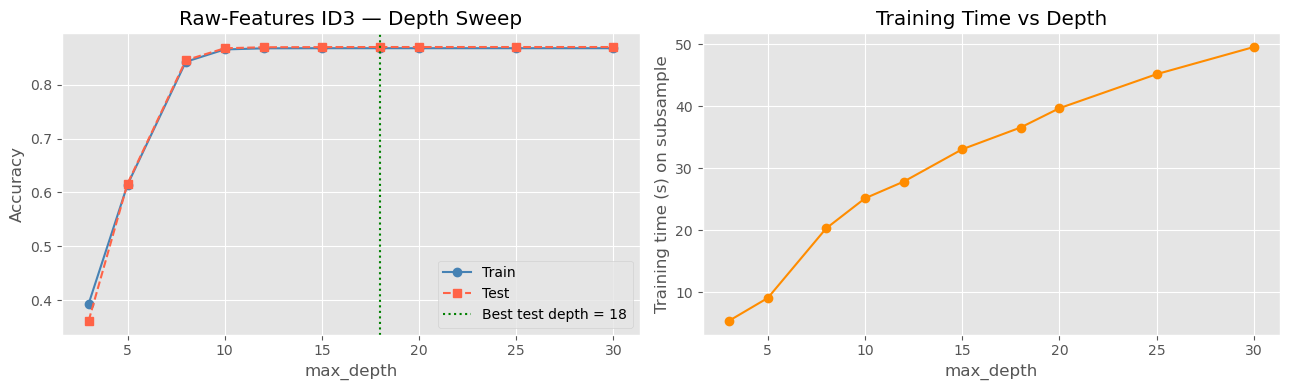


Recommended depth: 18
Update max_depth in src/decision_tree/id3_agent_raw.py, then run scripts/train_id3_raw.py


In [7]:
import time

# ── Configuration ────────────────────────────────────────────────────────────
RAW_OVERSAMPLE = 10      # must match ID3AgentRaw._OVERSAMPLE_FACTOR
SAMPLE_FRAC    = 0.05    # fraction of original dataset to sample (stratified)
DEPTH_VALUES   = [3, 5, 8, 10, 12, 15, 18, 20, 25, 30]

_EXCLUDE_RAW = {'best_move', 'is_proven', 'threats_me', 'threats_opp',
                'center_me', 'center_opp', 'phase', 'can_win', 'opp_wins_next'}
raw_feat_cols = [c for c in df.columns if c not in _EXCLUDE_RAW]

# ── Build subsample with correct proportions ─────────────────────────────────
# 1. Stratified sample from the ORIGINAL dataset (preserves class balance)
df_orig_sample = (
    df.groupby(TARGET, group_keys=False)
      .apply(lambda x: x.sample(frac=SAMPLE_FRAC, random_state=42))
      .reset_index(drop=True)
)

# 2. Apply the same oversampling as the full training run — on the sample,
#    not the full dataset, so we never materialise the full 1.3M row frame.
if 'is_proven' in df_orig_sample.columns:
    proven_s = df_orig_sample[df_orig_sample['is_proven'] == 1]
    df_sweep = pd.concat(
        [df_orig_sample] + [proven_s] * RAW_OVERSAMPLE, ignore_index=True
    )
    del proven_s
else:
    df_sweep = df_orig_sample.copy()

# 3. Convert to strings in-place
for c in raw_feat_cols:
    df_sweep[c] = df_sweep[c].astype(str)
df_sweep[TARGET] = df_sweep[TARGET].astype(str)

# 4. 80/20 split — test set keeps the oversampled proportions so accuracy
#    reflects the same distribution the full model trains and is tested on.
df_sw_train = df_sweep.sample(frac=0.8, random_state=42).reset_index(drop=True)
df_sw_test  = df_sweep.drop(df_sw_train.index).reset_index(drop=True)

print(f'Original sample : {len(df_orig_sample):,} rows  '
      f'(proven share: {(df_orig_sample["is_proven"]==1).mean():.1%})')
print(f'After oversampling: {len(df_sweep):,} rows  '
      f'(proven share: {(df_sweep["is_proven"].astype(str)=="1").mean():.1%})')
print(f'Train: {len(df_sw_train):,}  |  Test: {len(df_sw_test):,}')
print(f'Features: {len(raw_feat_cols)}  (raw cells + current_player)')
print(f'Depths  : {DEPTH_VALUES}\n')

# ── Depth sweep ──────────────────────────────────────────────────────────────
depth_results = []
for depth in DEPTH_VALUES:
    clf_d = ID3Classifier(max_depth=depth)
    t0 = time.perf_counter()
    clf_d.fit(df_sw_train[raw_feat_cols + [TARGET]], target=TARGET)
    train_t = time.perf_counter() - t0
    train_a = clf_d.score(df_sw_train[raw_feat_cols + [TARGET]], target=TARGET)
    test_a  = clf_d.score(df_sw_test [raw_feat_cols + [TARGET]], target=TARGET)
    depth_results.append({'depth': depth, 'train': train_a, 'test': test_a, 't': train_t})
    print(f'depth={depth:2d}  train={train_a:.3f}  test={test_a:.3f}  ({train_t:.1f}s)')

depth_df = pd.DataFrame(depth_results)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(depth_df['depth'], depth_df['train'], 'o-', label='Train', color='steelblue')
axes[0].plot(depth_df['depth'], depth_df['test'],  's--', label='Test',  color='tomato')
best_depth = int(depth_df.loc[depth_df['test'].idxmax(), 'depth'])
axes[0].axvline(best_depth, color='green', linestyle=':',
                label=f'Best test depth = {best_depth}')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Raw-Features ID3 — Depth Sweep')
axes[0].legend()

axes[1].plot(depth_df['depth'], depth_df['t'], 'o-', color='darkorange')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('Training time (s) on subsample')
axes[1].set_title('Training Time vs Depth')

plt.tight_layout()
plt.show()

print(f'\nRecommended depth: {best_depth}')
print('Update max_depth in src/decision_tree/id3_agent_raw.py, then run scripts/train_id3_raw.py')
del df_sweep, df_sw_train, df_sw_test, df_orig_sample


In [10]:
import pickle, gc

PICKLE_PATH     = Path('../data/generated/id3_model.pkl')
PICKLE_RAW_PATH = Path('../data/generated/id3_model_raw.pkl')

_EXCLUDE_RAW = {'best_move', 'is_proven', 'threats_me', 'threats_opp',
                'center_me', 'center_opp', 'phase', 'can_win', 'opp_wins_next'}
RAW_OVERSAMPLE = 10
RAW_DEPTH      = best_depth if 'best_depth' in dir() else 18

# ── ID3 with engineered features (full dataset, mirrors train_id3.py) ───────
if PICKLE_PATH.exists():
    print(f'Loading clf_game from {PICKLE_PATH} ...')
    t0 = time.perf_counter()
    with open(PICKLE_PATH, 'rb') as f:
        clf_game = pickle.load(f)
    print(f'  Loaded in {time.perf_counter()-t0:.2f}s')
else:
    print('Training clf_game on full dataset (features, 4x proven oversampling)...')
    _df = df.copy()
    _feat_cols = [c for c in _df.columns if c not in ('best_move', 'is_proven')]
    if 'is_proven' in _df.columns:
        _proven = _df[_df['is_proven'] == 1]
        _df = pd.concat([_df] + [_proven] * 4, ignore_index=True)
        del _proven
    for c in _feat_cols: _df[c] = _df[c].astype(str)
    _df['best_move'] = _df['best_move'].astype(str)
    t0 = time.perf_counter()
    clf_game = ID3Classifier(max_depth=10)
    clf_game.fit(_df[_feat_cols + ['best_move']], target='best_move')
    print(f'  Trained in {time.perf_counter()-t0:.1f}s')
    del _df; gc.collect()
    PICKLE_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(PICKLE_PATH, 'wb') as f: pickle.dump(clf_game, f)
    print(f'  Saved to {PICKLE_PATH}')

# ── ID3 Raw (raw cells only, heavy proven oversampling) ───────────────────────
if PICKLE_RAW_PATH.exists():
    print(f'\nLoading clf_game_raw from {PICKLE_RAW_PATH} ...')
    t0 = time.perf_counter()
    with open(PICKLE_RAW_PATH, 'rb') as f:
        clf_game_raw = pickle.load(f)
    print(f'  Loaded in {time.perf_counter()-t0:.2f}s')
else:
    print(f'\nTraining clf_game_raw (raw cells, depth={RAW_DEPTH}, {RAW_OVERSAMPLE}x proven)...')
    _df_raw = df.copy()
    _raw_cols = [c for c in _df_raw.columns if c not in _EXCLUDE_RAW]
    if 'is_proven' in _df_raw.columns:
        _proven = _df_raw[_df_raw['is_proven'] == 1]
        _df_raw = pd.concat([_df_raw] + [_proven] * RAW_OVERSAMPLE, ignore_index=True)
        del _proven
    for c in _raw_cols: _df_raw[c] = _df_raw[c].astype(str)
    _df_raw['best_move'] = _df_raw['best_move'].astype(str)
    t0 = time.perf_counter()
    clf_game_raw = ID3Classifier(max_depth=RAW_DEPTH)
    clf_game_raw.fit(_df_raw[_raw_cols + ['best_move']], target='best_move')
    print(f'  Trained in {time.perf_counter()-t0:.1f}s')
    del _df_raw; gc.collect()
    PICKLE_RAW_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(PICKLE_RAW_PATH, 'wb') as f: pickle.dump(clf_game_raw, f)
    print(f'  Saved to {PICKLE_RAW_PATH}')


Loading clf_game from ../data/generated/id3_model.pkl ...
  Loaded in 0.02s

Training clf_game_raw (raw cells, depth=18, 10x proven)...
  Trained in 714.0s
  Saved to ../data/generated/id3_model_raw.pkl


In [11]:
from src.mcts.optimized.numba_mcts import warmup, FlatNumbaMCTS
from src.mcts.optimized.numba_solver import FlatNumbaSolverMCTS

print('Warming up Numba JIT (one-time cost, ~2–5 s) ...')
t0 = time.perf_counter()
warmup()   # covers FlatNumbaMCTS, NumbaMCTS, FlatNumbaSolverMCTS and all kernels
print(f'Warmup done in {time.perf_counter() - t0:.1f} s')

Warming up Numba JIT (one-time cost, ~2–5 s) ...
Warmup done in 0.4 s


In [12]:
def _label_to_move(label: str) -> int:
    move_type, col = label.split('_')
    return int(col) if move_type == 'drop' else int(col) + 7

def _features_full(board):
    """Extended features (summary + cells) — used by clf_game."""
    return {k: str(v) for k, v in extended_features(board).items()}

def _features_raw(board):
    """Raw cell features only — used by clf_game_raw."""
    return {k: str(v) for k, v in board.to_feature_dict().items()}

def tree_choose_move(clf, board, feat_fn):
    row  = pd.Series(feat_fn(board))
    move = _label_to_move(clf.predict_one(row))
    legal = board.legal_moves()
    return move if move in legal else random.choice(legal)

def play_one_game(clf, feat_fn, agent, tree_plays_as, mcts_iterations, max_moves=120):
    """Play one game; returns +1 (tree wins), -1 (tree loses), 0 (draw)."""
    board = PopOutBoard()
    for _ in range(max_moves):
        legal = board.legal_moves()
        if not legal:
            return 0
        mover = board.current_player
        move  = tree_choose_move(clf, board, feat_fn) if mover == tree_plays_as \
                else agent.run(board, iterations=mcts_iterations)
        board.apply_move(move)
        winner = evaluate_after_move(board, mover=mover)
        if winner != 0:
            return 1 if winner == tree_plays_as else -1
    return 0


In [13]:
EVAL_GAMES = 30

CONFIGS = {
    'FlatNumbaMCTS':       [100, 500, 1_000, 5_000, 10_000],
    'FlatNumbaSolverMCTS': [1_000, 5_000, 10_000, 50_000, 100_000],
}

TREE_MODELS = {
    'ID3 (features)': (clf_game,     _features_full),
    'ID3 Raw':        (clf_game_raw,  _features_raw),
}

# eval_results[(model_name, engine, iters)] -> (wins, losses, draws)
eval_results = {}

t0 = time.perf_counter()
for model_name, (clf, feat_fn) in TREE_MODELS.items():
    print(f'\n── {model_name} ──')
    for engine_name, iter_list in CONFIGS.items():
        for iters in iter_list:
            agent = (FlatNumbaMCTS(max_nodes=iters + 256)
                     if engine_name == 'FlatNumbaMCTS'
                     else FlatNumbaSolverMCTS(max_nodes=iters + 256))
            wins = losses = draws = 0
            for i in range(EVAL_GAMES):
                r = play_one_game(clf, feat_fn, agent, 1 if i % 2 == 0 else 2, iters)
                if r == 1:    wins   += 1
                elif r == -1: losses += 1
                else:         draws  += 1
            eval_results[(model_name, engine_name, iters)] = (wins, losses, draws)
            wr = wins / EVAL_GAMES
            print(f'  {engine_name:22s}  {iters:7,d} iter  →  {wr:5.1%}  '
                  f'({wins}W / {losses}L / {draws}D)')
        print()

print(f'Total evaluation time: {time.perf_counter() - t0:.1f} s')



── ID3 (features) ──
  FlatNumbaMCTS               100 iter  →  26.7%  (8W / 22L / 0D)
  FlatNumbaMCTS               500 iter  →  13.3%  (4W / 26L / 0D)
  FlatNumbaMCTS             1,000 iter  →  16.7%  (5W / 25L / 0D)
  FlatNumbaMCTS             5,000 iter  →  43.3%  (13W / 17L / 0D)
  FlatNumbaMCTS            10,000 iter  →  43.3%  (13W / 17L / 0D)

  FlatNumbaSolverMCTS       1,000 iter  →  26.7%  (8W / 22L / 0D)
  FlatNumbaSolverMCTS       5,000 iter  →  36.7%  (11W / 19L / 0D)
  FlatNumbaSolverMCTS      10,000 iter  →  50.0%  (15W / 15L / 0D)
  FlatNumbaSolverMCTS      50,000 iter  →  46.7%  (14W / 16L / 0D)
  FlatNumbaSolverMCTS     100,000 iter  →  53.3%  (16W / 14L / 0D)


── ID3 Raw ──
  FlatNumbaMCTS               100 iter  →  46.7%  (14W / 16L / 0D)
  FlatNumbaMCTS               500 iter  →  10.0%  (3W / 27L / 0D)
  FlatNumbaMCTS             1,000 iter  →  30.0%  (9W / 21L / 0D)
  FlatNumbaMCTS             5,000 iter  →  40.0%  (12W / 18L / 0D)
  FlatNumbaMCTS            10

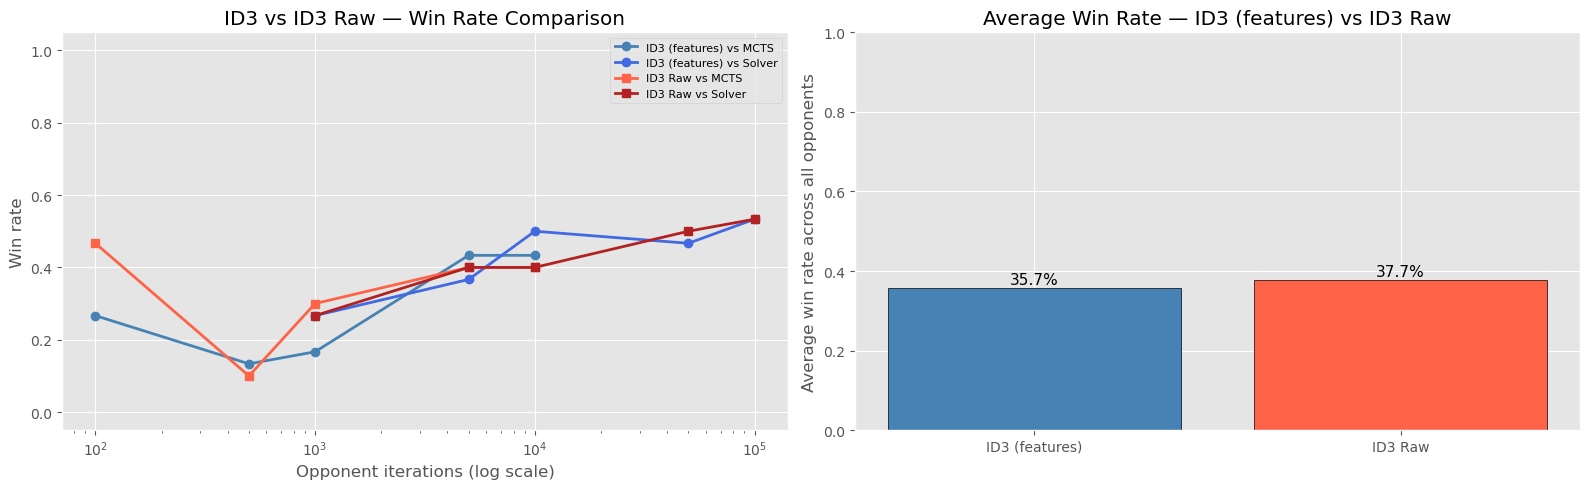


Model                 Opponent engine         Iterations     Win%     W     L     D
───────────────────────────────────────────────────────────────────────────
ID3 (features)        FlatNumbaMCTS                  100    26.7%     8    22     0
ID3 (features)        FlatNumbaMCTS                  500    13.3%     4    26     0
ID3 (features)        FlatNumbaMCTS                1,000    16.7%     5    25     0
ID3 (features)        FlatNumbaMCTS                5,000    43.3%    13    17     0
ID3 (features)        FlatNumbaMCTS               10,000    43.3%    13    17     0
ID3 (features)        FlatNumbaSolverMCTS          1,000    26.7%     8    22     0
ID3 (features)        FlatNumbaSolverMCTS          5,000    36.7%    11    19     0
ID3 (features)        FlatNumbaSolverMCTS         10,000    50.0%    15    15     0
ID3 (features)        FlatNumbaSolverMCTS         50,000    46.7%    14    16     0
ID3 (features)        FlatNumbaSolverMCTS        100,000    53.3%    16    14     0

In [14]:
ENGINE_SHORT = {'FlatNumbaMCTS': 'MCTS', 'FlatNumbaSolverMCTS': 'Solver'}
MODEL_COLORS = {'ID3 (features)': {'FlatNumbaMCTS': 'steelblue', 'FlatNumbaSolverMCTS': 'royalblue'},
                'ID3 Raw':        {'FlatNumbaMCTS': 'tomato',    'FlatNumbaSolverMCTS': 'firebrick'}}
MODEL_MARKERS = {'ID3 (features)': 'o', 'ID3 Raw': 's'}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: win rate vs opponent strength, one line per (model, engine)
for model_name, (clf, _) in TREE_MODELS.items():
    for engine_name, iter_list in CONFIGS.items():
        win_rates = [eval_results[(model_name, engine_name, it)][0] / EVAL_GAMES
                     for it in iter_list]
        axes[0].plot(iter_list, win_rates,
                     marker=MODEL_MARKERS[model_name], linestyle='-',
                     color=MODEL_COLORS[model_name][engine_name], linewidth=2,
                     label=f'{model_name} vs {ENGINE_SHORT[engine_name]}')
axes[0].set_xscale('log')
axes[0].set_xlabel('Opponent iterations (log scale)')
axes[0].set_ylabel('Win rate')
axes[0].set_title('ID3 vs ID3 Raw — Win Rate Comparison')
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend(fontsize=8)

# Right: summary table as grouped bars — avg win rate across all opponents
model_names = list(TREE_MODELS.keys())
avg_wr = [
    np.mean([eval_results[(m, eng, it)][0] / EVAL_GAMES
              for eng, iters in CONFIGS.items() for it in iters])
    for m in model_names
]
bar_colors = ['steelblue', 'tomato']
axes[1].bar(model_names, avg_wr, color=bar_colors, edgecolor='black')
for i, v in enumerate(avg_wr):
    axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=11)
axes[1].set_ylabel('Average win rate across all opponents')
axes[1].set_title('Average Win Rate — ID3 (features) vs ID3 Raw')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Summary table
print(f'\n{"Model":<20}  {"Opponent engine":<22}  {"Iterations":>10}  '
      f'{"Win%":>7}  {"W":>4}  {"L":>4}  {"D":>4}')
print('─' * 75)
for model_name in TREE_MODELS:
    for engine_name, iter_list in CONFIGS.items():
        for it in iter_list:
            w, l, d = eval_results[(model_name, engine_name, it)]
            print(f'{model_name:<20}  {engine_name:<22}  {it:>10,}  '
                  f'{w/EVAL_GAMES:>7.1%}  {w:>4}  {l:>4}  {d:>4}')
    print()